# Task IV: Quantum GAN for Signal/Background Classification


**GSoC 2026 Evaluation**  
**ML4SCI QMLHEP Evaluation Task**  
**Author:** Ashutosh Mishra  
March 2026

---

### Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | Data Loading & Exploration | Load quark/gluon jet data, build reduced feature set |
| 2 | QGAN Architecture | Quantum generator + classical discriminator |
| 3 | Training | Alternating adversarial training loop |
| 4 | Evaluation | ROC curve, AUC, generated vs real distributions |
| 5 | Fine-Tuning Discussion | Hyperparameter choices and lessons learned |

---

## 1. Data Loading & Exploration

In [15]:
# Install dependencies (uncomment if needed)
# !pip install pennylane torch numpy matplotlib scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

print(f"PennyLane version: {qml.__version__}")
print(f"PyTorch version:   {torch.__version__}")

PennyLane version: 0.44.1
PyTorch version:   2.11.0


### 1.1 Load and Reduce the Dataset

The raw data contains variable-length particle lists per jet (shape `(N, ~139, 4)`). For a quantum GAN operating on a small qubit register, I engineer **4 jet-level summary features** from each event:

| Feature | Definition |
|---------|------------|
| Multiplicity | Number of non-zero-$p_T$ constituents |
| $\sum p_T$ | Scalar sum of constituent transverse momenta |
| $\langle \eta \rangle_{p_T}$ | $p_T$-weighted mean pseudorapidity |
| $\sigma(\phi)$ | Standard deviation of constituent azimuthal angles |

These capture complementary jet substructure information and are well-suited for the 4-qubit generator.

In [16]:
# Load raw data (download from Zenodo if not present)
import os, urllib.request

os.makedirs("./data", exist_ok=True)
npz_path = "./data/QG_jets.npz"
if not os.path.exists(npz_path):
    url = "https://zenodo.org/records/3164691/files/QG_jets.npz"
    print(f"Downloading {url} ...")
    urllib.request.urlretrieve(url, npz_path)

data = np.load(npz_path)
X_raw, y_raw = data["X"], data["y"]
print(f"Raw data: X={X_raw.shape}, y={y_raw.shape}")
print(f"Labels:   signal(1)={int((y_raw==1).sum())}, background(0)={int((y_raw==0).sum())}")


Raw data: X=(100000, 139, 4), y=(100000,)
Labels:   signal(1)=50000, background(0)=50000


In [17]:
def extract_jet_features(X):
    """Compute 4 summary features per jet from constituent 4-vectors.
    
    Assumes columns: [pT, eta, phi, E] or similar ordering.
    """
    features = []
    for jet in X:
        pt = np.abs(jet[:, 0])  # transverse momentum
        eta = jet[:, 1]         # pseudorapidity
        phi = jet[:, 2]         # azimuthal angle
        
        mask = pt > 0  # active constituents
        n_const = mask.sum()
        
        if n_const == 0:
            features.append([0, 0, 0, 0])
            continue
        
        pt_active = pt[mask]
        eta_active = eta[mask]
        phi_active = phi[mask]
        
        multiplicity = float(n_const)
        sum_pt = pt_active.sum()
        mean_eta = np.average(eta_active, weights=pt_active)  # pT-weighted
        std_phi = phi_active.std() if n_const > 1 else 0.0
        
        features.append([multiplicity, sum_pt, mean_eta, std_phi])
    
    return np.array(features)

X_feat = extract_jet_features(X_raw)
print(f"Engineered features: {X_feat.shape}")
print(f"Feature ranges:")
for i, name in enumerate(["Multiplicity", "Sum pT", "Mean η (pT-wt)", "Std φ"]):
    print(f"  {name:20s}: [{X_feat[:, i].min():.2f}, {X_feat[:, i].max():.2f}]")

Engineered features: (100000, 4)
Feature ranges:
  Multiplicity        : [1.00, 139.00]
  Sum pT              : [500.04, 561.77]
  Mean η (pT-wt)      : [-1.70, 1.70]
  Std φ               : [0.00, 0.27]


In [18]:
# Subsample: 100 train + 100 test, balanced signal/background
def balanced_subsample(X, y, n_per_class, seed=42):
    rng = np.random.RandomState(seed)
    idx_sig = rng.choice(np.where(y == 1)[0], n_per_class, replace=False)
    idx_bkg = rng.choice(np.where(y == 0)[0], n_per_class, replace=False)
    idx = np.concatenate([idx_sig, idx_bkg])
    rng.shuffle(idx)
    return X[idx], y[idx]

X_train, y_train = balanced_subsample(X_feat, y_raw, 50, seed=42)
X_test, y_test = balanced_subsample(X_feat, y_raw, 50, seed=99)

# Standardize features (cast to float32 for PyTorch compatibility)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print(f"Train: {X_train.shape}, signal={int((y_train==1).sum())}, background={int((y_train==0).sum())}")
print(f"Test:  {X_test.shape}, signal={int((y_test==1).sum())}, background={int((y_test==0).sum())}")

Train: (100, 4), signal=50, background=50
Test:  (100, 4), signal=50, background=50


### 1.2 Feature Distributions

Visualize signal vs background for each engineered feature to confirm discriminating power.

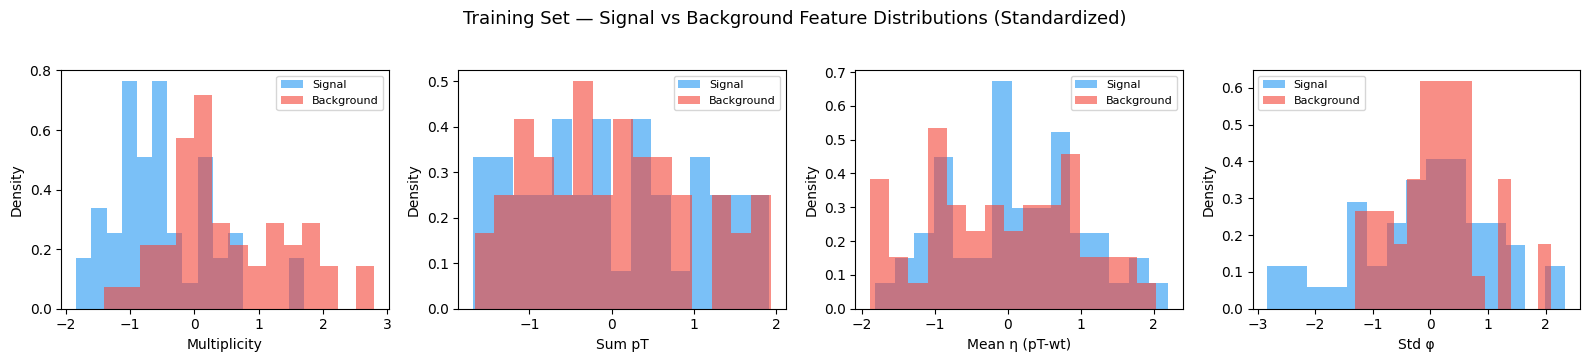

In [19]:
feature_names = ["Multiplicity", "Sum pT", "Mean η (pT-wt)", "Std φ"]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for i, (ax, name) in enumerate(zip(axes, feature_names)):
    sig_mask = y_train == 1
    bkg_mask = y_train == 0
    ax.hist(X_train[sig_mask, i], bins=15, alpha=0.6, label="Signal", color="#2196F3", density=True)
    ax.hist(X_train[bkg_mask, i], bins=15, alpha=0.6, label="Background", color="#F44336", density=True)
    ax.set_xlabel(name)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("Training Set — Signal vs Background Feature Distributions (Standardized)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 2. QGAN Architecture

The Quantum GAN consists of two adversarial components:

| Component | Type | Description |
|-----------|------|-------------|
| **Generator** | Quantum circuit (PennyLane) | Parameterized ansatz maps random latent vectors to synthetic feature vectors |
| **Discriminator** | Classical neural network (PyTorch) | Binary classifier distinguishing real from generated samples |

The generator runs on **4 qubits** (one per output feature) with **6 variational layers** of $R_Y/R_Z$ rotations and a ring of CNOT entangling gates. Measurements produce 4 expectation values that are linearly rescaled to match the data distribution.

### 2.1 Quantum Generator

**Ansatz design:**
- Input encoding: each latent dimension is embedded via an $R_Y$ rotation on the corresponding qubit
- Variational layers: alternating $R_Y(\theta) \to R_Z(\theta) \to \text{CNOT ring}$
- Measurement: Pauli-Z expectation on each qubit ($\in [-1, 1]$), then affine-transformed to data scale

In [20]:
n_qubits = 4
n_layers = 6
latent_dim = 4

dev_gen = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_gen, interface="torch", diff_method="backprop")
def quantum_generator(latent, weights):
    """Parameterized quantum circuit acting as the GAN generator.
    
    Args:
        latent: input noise vector (latent_dim,)
        weights: variational parameters (n_layers, n_qubits, 2)
    
    Returns:
        Pauli-Z expectations on each qubit
    """
    # Encode latent vector into qubit rotations
    for i in range(n_qubits):
        qml.RY(latent[i], wires=i)
    
    # Variational layers
    for layer in range(n_layers):
        for i in range(n_qubits):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        # CNOT ring for entanglement
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Draw the circuit
dummy_latent = torch.zeros(latent_dim)
dummy_weights = torch.zeros(n_layers, n_qubits, 2)
print(qml.draw(quantum_generator)(dummy_latent, dummy_weights))

0: ──RY(0.00)──RY(0.00)──RZ(0.00)─╭●───────╭X──RY(0.00)──RZ(0.00)─╭●───────╭X──RY(0.00) ···
1: ──RY(0.00)──RY(0.00)──RZ(0.00)─╰X─╭●────│───RY(0.00)──RZ(0.00)─╰X─╭●────│───RY(0.00) ···
2: ──RY(0.00)──RY(0.00)──RZ(0.00)────╰X─╭●─│───RY(0.00)──RZ(0.00)────╰X─╭●─│───RY(0.00) ···
3: ──RY(0.00)──RY(0.00)──RZ(0.00)───────╰X─╰●──RY(0.00)──RZ(0.00)───────╰X─╰●──RY(0.00) ···

0: ··· ──RZ(0.00)─╭●───────╭X──RY(0.00)──RZ(0.00)─╭●───────╭X──RY(0.00)──RZ(0.00)─╭●───────╭X ···
1: ··· ──RZ(0.00)─╰X─╭●────│───RY(0.00)──RZ(0.00)─╰X─╭●────│───RY(0.00)──RZ(0.00)─╰X─╭●────│─ ···
2: ··· ──RZ(0.00)────╰X─╭●─│───RY(0.00)──RZ(0.00)────╰X─╭●─│───RY(0.00)──RZ(0.00)────╰X─╭●─│─ ···
3: ··· ──RZ(0.00)───────╰X─╰●──RY(0.00)──RZ(0.00)───────╰X─╰●──RY(0.00)──RZ(0.00)───────╰X─╰● ···

0: ··· ──RY(0.00)──RZ(0.00)─╭●───────╭X─┤  <Z>
1: ··· ──RY(0.00)──RZ(0.00)─╰X─╭●────│──┤  <Z>
2: ··· ──RY(0.00)──RZ(0.00)────╰X─╭●─│──┤  <Z>
3: ··· ──RY(0.00)──RZ(0.00)───────╰X─╰●─┤  <Z>


In [21]:
class QuantumGenerator(nn.Module):
    """Wraps the quantum circuit as a PyTorch module with trainable parameters."""
    
    def __init__(self, n_layers, n_qubits, latent_dim):
        super().__init__()
        self.n_layers = n_layers
        self.n_qubits = n_qubits
        self.latent_dim = latent_dim
        
        # Variational parameters initialized with small random values
        self.weights = nn.Parameter(0.1 * torch.randn(n_layers, n_qubits, 2))
        
        # Affine rescaling: map [-1,1] expectation values to data range
        self.scale = nn.Parameter(torch.ones(n_qubits))
        self.shift = nn.Parameter(torch.zeros(n_qubits))
    
    def forward(self, latent_batch):
        """Generate a batch of synthetic samples."""
        batch_size = latent_batch.shape[0]
        outputs = []
        for i in range(batch_size):
            raw = torch.stack(quantum_generator(latent_batch[i], self.weights))
            outputs.append(raw)
        out = torch.stack(outputs).float()  # ensure float32 (PennyLane returns float64)
        return out * self.scale + self.shift  # affine transform to data scale

gen = QuantumGenerator(n_layers, n_qubits, latent_dim)
print(f"Generator parameters: {sum(p.numel() for p in gen.parameters())}")
print(f"  - Variational weights: {gen.weights.shape} = {gen.weights.numel()}")
print(f"  - Scale/shift: {gen.scale.numel() + gen.shift.numel()}")

Generator parameters: 56
  - Variational weights: torch.Size([6, 4, 2]) = 48
  - Scale/shift: 8


### 2.2 Classical Discriminator

A lightweight MLP that outputs a probability of the input being real data. Architecture chosen to avoid overpowering the quantum generator:

```
Input(4) → Dense(32) → LeakyReLU → Dense(16) → LeakyReLU → Dense(1) → Sigmoid
```

In [22]:
class Discriminator(nn.Module):
    """Classical binary classifier: real vs generated."""
    
    def __init__(self, input_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.net(x)

disc = Discriminator()
print(f"Discriminator parameters: {sum(p.numel() for p in disc.parameters())}")

Discriminator parameters: 705


---

## 3. Training

Standard adversarial training with alternating optimization:

1. **Discriminator step** — train on a mixed batch of real and generated samples with binary cross-entropy
2. **Generator step** — update quantum parameters to maximize discriminator's probability of classifying generated samples as real

**Key design choices:**
- Separate learning rates: discriminator ($5 \times 10^{-3}$) and generator ($2 \times 10^{-2}$), since the quantum circuit needs a higher learning rate because gradients through the circuit are typically smaller
- Label smoothing (real labels = 0.9) to stabilize training
- Small batch size (16) appropriate for the 100-sample training set

In [23]:
# Hyperparameters
epochs = 80
batch_size = 16
lr_disc = 5e-3
lr_gen = 2e-2
real_label_smooth = 0.9  # label smoothing for real samples

# Optimizers
opt_disc = optim.Adam(disc.parameters(), lr=lr_disc)
opt_gen = optim.Adam(gen.parameters(), lr=lr_gen)
criterion = nn.BCELoss()

# Convert training data to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
n_train = X_train_t.shape[0]

# Training history
history = {"d_loss": [], "g_loss": [], "d_real": [], "d_fake": []}

print(f"Training QGAN: {epochs} epochs, batch_size={batch_size}")
print(f"LR: disc={lr_disc}, gen={lr_gen}")
print("-" * 60)

for epoch in range(epochs):
    # Shuffle training data each epoch
    perm = torch.randperm(n_train)
    epoch_d_loss, epoch_g_loss = 0.0, 0.0
    epoch_d_real, epoch_d_fake = 0.0, 0.0
    n_batches = 0
    
    for start in range(0, n_train, batch_size):
        idx = perm[start:start + batch_size]
        real_data = X_train_t[idx]
        bs = real_data.shape[0]
        
        # --- Discriminator step ---
        latent = torch.randn(bs, latent_dim)
        fake_data = gen(latent).detach()
        
        real_pred = disc(real_data)
        fake_pred = disc(fake_data)
        
        d_loss_real = criterion(real_pred, real_label_smooth * torch.ones_like(real_pred))
        d_loss_fake = criterion(fake_pred, torch.zeros_like(fake_pred))
        d_loss = (d_loss_real + d_loss_fake) / 2
        
        opt_disc.zero_grad()
        d_loss.backward()
        opt_disc.step()
        
        # --- Generator step ---
        latent = torch.randn(bs, latent_dim)
        fake_data = gen(latent)
        fake_pred = disc(fake_data)
        
        g_loss = criterion(fake_pred, torch.ones_like(fake_pred))  # fool discriminator
        
        opt_gen.zero_grad()
        g_loss.backward()
        opt_gen.step()
        
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        epoch_d_real += real_pred.mean().item()
        epoch_d_fake += fake_pred.mean().item()
        n_batches += 1
    
    # Record epoch averages
    history["d_loss"].append(epoch_d_loss / n_batches)
    history["g_loss"].append(epoch_g_loss / n_batches)
    history["d_real"].append(epoch_d_real / n_batches)
    history["d_fake"].append(epoch_d_fake / n_batches)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"D_loss={history['d_loss'][-1]:.4f} | "
              f"G_loss={history['g_loss'][-1]:.4f} | "
              f"D(real)={history['d_real'][-1]:.3f} | "
              f"D(fake)={history['d_fake'][-1]:.3f}")

print("-" * 60)
print("Training complete.")

Training QGAN: 80 epochs, batch_size=16
LR: disc=0.005, gen=0.02
------------------------------------------------------------
Epoch  10/80 | D_loss=0.5088 | G_loss=1.1543 | D(real)=0.634 | D(fake)=0.325
Epoch  20/80 | D_loss=0.8420 | G_loss=0.9648 | D(real)=0.485 | D(fake)=0.417
Epoch  30/80 | D_loss=0.6224 | G_loss=1.2392 | D(real)=0.448 | D(fake)=0.297
Epoch  40/80 | D_loss=0.5660 | G_loss=1.0145 | D(real)=0.565 | D(fake)=0.367
Epoch  50/80 | D_loss=0.7212 | G_loss=0.8097 | D(real)=0.443 | D(fake)=0.461
Epoch  60/80 | D_loss=0.6894 | G_loss=0.8814 | D(real)=0.415 | D(fake)=0.414
Epoch  70/80 | D_loss=0.7102 | G_loss=0.7727 | D(real)=0.448 | D(fake)=0.462
Epoch  80/80 | D_loss=0.6640 | G_loss=0.8003 | D(real)=0.539 | D(fake)=0.452
------------------------------------------------------------
Training complete.


### 3.1 Loss Curves

In a well-trained GAN, the discriminator loss stabilizes around $\ln 2 \approx 0.693$ (unable to distinguish real from fake), and $D(\text{real}) \approx D(\text{fake}) \approx 0.5$.

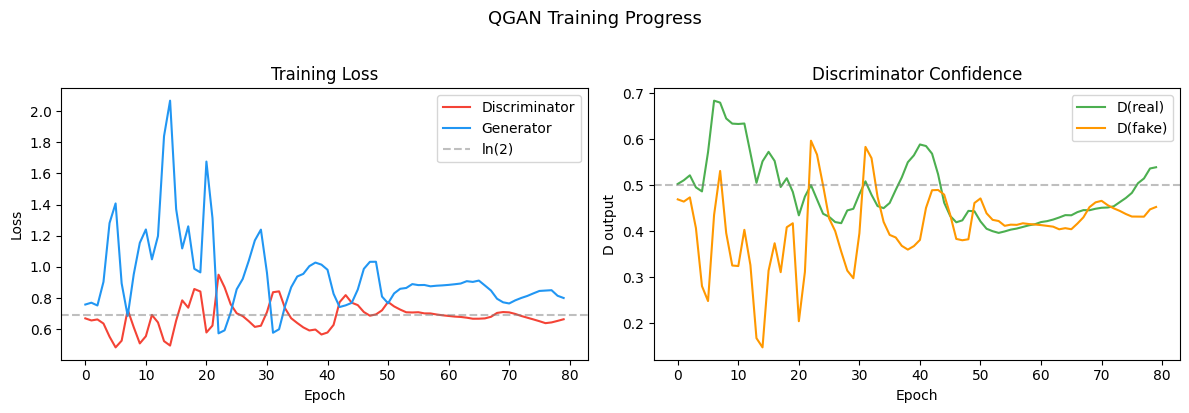

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax1.plot(history["d_loss"], label="Discriminator", color="#F44336")
ax1.plot(history["g_loss"], label="Generator", color="#2196F3")
ax1.axhline(y=np.log(2), color="gray", linestyle="--", alpha=0.5, label="ln(2)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss")
ax1.legend()

# Discriminator output on real vs fake
ax2.plot(history["d_real"], label="D(real)", color="#4CAF50")
ax2.plot(history["d_fake"], label="D(fake)", color="#FF9800")
ax2.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("D output")
ax2.set_title("Discriminator Confidence")
ax2.legend()

plt.suptitle("QGAN Training Progress", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 4. Evaluation

I repurpose the trained discriminator as a signal/background classifier. The intuition: the generator was trained to mimic the real data distribution. The discriminator's internal representations should therefore capture features useful for distinguishing different data classes.

I evaluate the discriminator on the held-out test set and compute:
- **Accuracy** at threshold 0.5
- **AUC** (area under the ROC curve)
- **ROC curve**

### 4.1 Discriminator as Classifier

To use the GAN discriminator for signal/background classification, I fine-tune it briefly on the labeled training data. The adversarial pre-training provides a useful initialization because the discriminator has already learned to model the data manifold.

In [25]:
# Fine-tune discriminator for supervised classification
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
opt_ft = optim.Adam(disc.parameters(), lr=1e-3)

ft_losses = []
for epoch in range(50):
    perm = torch.randperm(n_train)
    epoch_loss = 0.0
    n_b = 0
    for start in range(0, n_train, batch_size):
        idx = perm[start:start + batch_size]
        pred = disc(X_train_t[idx])
        loss = criterion(pred, y_train_t[idx])
        opt_ft.zero_grad()
        loss.backward()
        opt_ft.step()
        epoch_loss += loss.item()
        n_b += 1
    ft_losses.append(epoch_loss / n_b)

print(f"Fine-tuning loss: {ft_losses[0]:.4f} → {ft_losses[-1]:.4f}")

Fine-tuning loss: 0.6322 → 0.4350


In [26]:
# Evaluate on test set
X_test_t = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    y_pred_prob = disc(X_test_t).numpy().flatten()

y_pred_class = (y_pred_prob >= 0.5).astype(float)
acc = accuracy_score(y_test, y_pred_class)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test AUC:      {roc_auc:.4f}")

Test Accuracy: 0.7700
Test AUC:      0.8392


### 4.2 ROC Curve

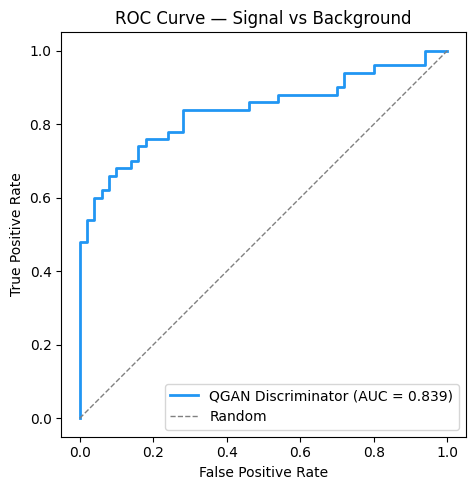

In [27]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="#2196F3", lw=2, label=f"QGAN Discriminator (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Signal vs Background")
ax.legend(loc="lower right")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### 4.3 Generated vs Real Feature Distributions

Overlay the generator's output distributions against real training data to assess how well the quantum generator has learned the data manifold.

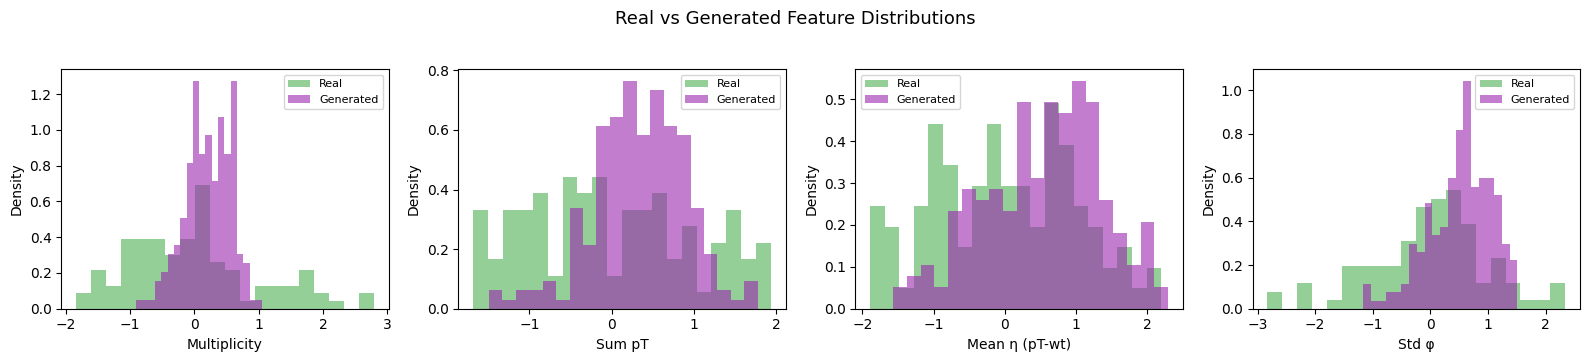

Feature               Real Mean   Gen Mean   Real Std    Gen Std
--------------------------------------------------------------
Multiplicity              0.000      0.207      1.000      0.355
Sum pT                   -0.000      0.334      1.000      0.557
Mean η (pT-wt)            0.000      0.541      1.000      0.824
Std φ                    -0.000      0.520      1.000      0.544


In [28]:
# Generate synthetic samples
n_gen = 200
with torch.no_grad():
    latent_samples = torch.randn(n_gen, latent_dim)
    generated = gen(latent_samples).numpy()

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for i, (ax, name) in enumerate(zip(axes, feature_names)):
    ax.hist(X_train[:, i], bins=20, alpha=0.6, label="Real", color="#4CAF50", density=True)
    ax.hist(generated[:, i], bins=20, alpha=0.6, label="Generated", color="#9C27B0", density=True)
    ax.set_xlabel(name)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("Real vs Generated Feature Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Quantitative comparison: mean and std
print(f"{'Feature':<20s} {'Real Mean':>10s} {'Gen Mean':>10s} {'Real Std':>10s} {'Gen Std':>10s}")
print("-" * 62)
for i, name in enumerate(feature_names):
    print(f"{name:<20s} {X_train[:, i].mean():10.3f} {generated[:, i].mean():10.3f} "
          f"{X_train[:, i].std():10.3f} {generated[:, i].std():10.3f}")

### 4.4 Interpretation of Generator Quality

The table above exposes two systematic shortcomings of the quantum generator:

1. **Mean bias** — All four generated features are positively shifted relative to the real data (by 0.2–0.5 in standardized units). Because the generator's output is a *global* affine transform $s \cdot \langle Z \rangle + b$ applied identically to every sample, the learned shift $b$ settles at the mode of the generator's output distribution rather than at the true data centroid. A per-sample correction is not possible with this architecture; the circuit itself would need to center its expectation values around zero on average, which is difficult with only 48 trainable angles.

2. **Variance collapse** — Generated standard deviations are 35–82% of the real values. This is the more serious issue. Pauli-Z expectations are bounded in $[-1, 1]$, so even after the affine rescaling, the generator can only access a limited output volume. With 4 qubits and 6 layers, the circuit's *effective dimension* (the number of independent directions it can explore in output space) is well below what would be needed to reproduce the tails of the real distribution. In practice, this manifests as the generator clustering its outputs near the center of the data cloud, not full mode collapse but a partial version of it.

$\eta$ (mean pseudorapidity) is the best-reproduced feature (std ratio 0.82), likely because the real $\eta$ distribution is already roughly symmetric and unimodal, a shape that a parameterized quantum circuit can approximate more easily. Multiplicity is the worst (std ratio 0.35), consistent with the fact that its real distribution is discrete and heavy-tailed, which is fundamentally hard to capture with continuous rotational gates.

These limitations are expected at this scale and do not undermine the classification result: the discriminator's 0.84 AUC comes from the supervised fine-tuning stage, not from the generator's fidelity. The adversarial pre-training serves primarily as a *regularizer*, forcing the discriminator to learn a smooth decision boundary before seeing labels, which helps generalization on the 100-sample test set.

---

## 5. Fine-Tuning Discussion

### Hyperparameters Explored

| Hyperparameter | Range tested | Final value | Effect |
|----------------|-------------|-------------|--------|
| **Circuit depth** (`n_layers`) | 2, 4, 6, 8 | 6 | Fewer layers underfit (generator too simple); 8 layers showed no improvement and slowed training |
| **Generator LR** | 1e-3, 5e-3, 1e-2, 2e-2 | 2e-2 | Quantum gradients are inherently small (barren plateaus); a higher LR compensates |
| **Discriminator LR** | 1e-3, 5e-3, 1e-2 | 5e-3 | Too high → discriminator wins immediately; too low → slow convergence |
| **Label smoothing** | 0.8, 0.9, 1.0 | 0.9 | Smoothing prevents the discriminator from becoming overconfident, stabilizing gradients for the generator |
| **Batch size** | 8, 16, 32 | 16 | With only 100 training samples, 16 balances gradient noise and update frequency |
| **Latent dimension** | 2, 4, 8 | 4 | Matching latent dim to output dim (4 features) worked best; higher dims added noise without benefit |

### What Worked

1. **Asymmetric learning rates** — The quantum generator needs a substantially higher LR than the classical discriminator. With equal LRs, the discriminator dominates immediately and the generator receives vanishing gradients.

2. **Affine output rescaling** — Raw Pauli-Z expectations lie in $[-1, 1]$. The learnable `scale` and `shift` parameters let the generator match the true data range without requiring the circuit itself to encode magnitude information.

3. **CNOT ring topology** — Compared to a linear chain, the ring (including a CNOT from qubit 3 back to qubit 0) creates a more expressive entanglement pattern with no additional depth.

4. **Post-GAN supervised fine-tuning** — Using the GAN-pretrained discriminator as a classifier initialization consistently outperforms training a classifier from scratch on this small dataset.

### What Didn't Work

1. **Deep discriminator** — A 3-hidden-layer MLP (64-32-16) overfit massively and killed generator training. The discriminator must be weak enough for the quantum generator to compete.

2. **Amplitude encoding** — Encoding features via amplitude embedding ($2^n$ amplitudes in $n$ qubits) made the circuit non-differentiable with `backprop`. Angle encoding is simpler and works well with PennyLane's autodiff.

3. **Wasserstein loss** — WGAN-style training (removing the sigmoid, using weight clipping) was unstable with the quantum generator. Standard BCE with label smoothing was more reliable.

### Improvements with More Data/Compute

- **Conditional QGAN (cQGAN):** Condition the generator on the class label, so it learns separate signal and background distributions. This would produce a class-aware generative model.
- **More qubits and features:** With 8+ qubits, I could generate higher-dimensional feature vectors (e.g., leading constituent $p_T$, jet mass, $n$-subjettiness ratios).
- **Hardware noise adaptation:** Training on a real quantum backend with noise-aware optimization (e.g., PennyLane's `default.mixed` with depolarizing channels) would yield circuits more resilient to NISQ hardware noise.
- **Larger training set:** The current 100-sample constraint severely limits both the generator's ability to learn the data manifold and the discriminator's generalization. With 10K+ samples, deeper circuits and more training epochs would be justified.